# Bank Customer Churn Analysis

Analyzing customer data from a bank to understand why customers are leaving and which factors matter most.

Dataset: 10,000 customers with details like credit score, age, geography, balance, products used, complaints, and satisfaction score.

Goal: find patterns in churn and give the bank useful insights to reduce customer loss.

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

## Loading The Data

In [2]:
df= pd.read_csv("Customer-Churn-Records.csv") 
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


Reading the csv file and taking a first look at the data.

## Data Overview

In [3]:
df.head(10) 

df.tail(8)

df.shape # (10000, 18)

df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')

## Checking Data Quality

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

No missing values, no duplicate rows. Data is clean so not much cleaning was needed.

## Statistical Summary

In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [6]:
df.duplicated().sum() # 0

np.int64(0)

In [7]:
df.nunique() # Unique values

RowNumber             10000
CustomerId            10000
Surname                2932
CreditScore             460
Geography                 3
Gender                    2
Age                      70
Tenure                   11
Balance                6382
NumOfProducts             4
HasCrCard                 2
IsActiveMember            2
EstimatedSalary        9999
Exited                    2
Complain                  2
Satisfaction Score        5
Card Type                 4
Point Earned            785
dtype: int64

In [8]:
df["Exited"].value_counts() # Display churn count

Exited
0    7962
1    2038
Name: count, dtype: int64

In [9]:
df["Gender"].value_counts() # Male = 5457, Female = 4543

df["Geography"].value_counts() # France = 5014, Germany = 2509, Spain = 2477

df["Card Type"].value_counts() # Diamond = 2507, Gold = 2502, Silver = 2496, Platinum = 2495

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

## Feature Engineering

In [10]:
bins = [18, 30, 40, 50, 60, 70, 100] 
labels = ["18-30", "31-40", "41-50", "51-60", "61-70", "70+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

Age and credit score are continuous numbers. Grouping them into ranges makes it easier to compare churn across groups.

In [11]:
df["Age Group"].value_counts() # Age group distribution

Age Group
31-40    4451
41-50    2320
18-30    1946
51-60     797
61-70     331
70+       133
Name: count, dtype: int64

In [12]:
bins = [300, 450, 550, 650, 750, 850] # Create Credit Score Groups
labels = ["300-449", "450-549", "550-649", "650-749", "750-850"]

df["Credit Score Group"] = pd.cut(df["CreditScore"], bins=bins, labels=labels)

In [13]:
df["Credit Score Group"].value_counts() # Credit Score Dsitribution

Credit Score Group
650-749    3465
550-649    3316
750-850    1598
450-549    1432
300-449     189
Name: count, dtype: int64

## Key Metrics

A quick summary before the detailed charts.

In [14]:
total_customers = len(df)
total_customers # 10000

active_members = df["IsActiveMember"].sum()
active_members # 5151

churn_rate = df["Exited"].mean() * 100
churn_rate # 20.4

average_balance = df["Balance"].mean()
average_balance # 76485.8

np.float64(76485.889288)

Out of 10,000 customers, 20.4% have churned. That is quite high for a bank. About half the customers are active members, and the average balance is around 76,000.

## Visualizing The Data

In [15]:
plt.style.use("dark_background")
sb.set_style("dark")

Setting a dark theme for the charts to match the dashboard used in this project.

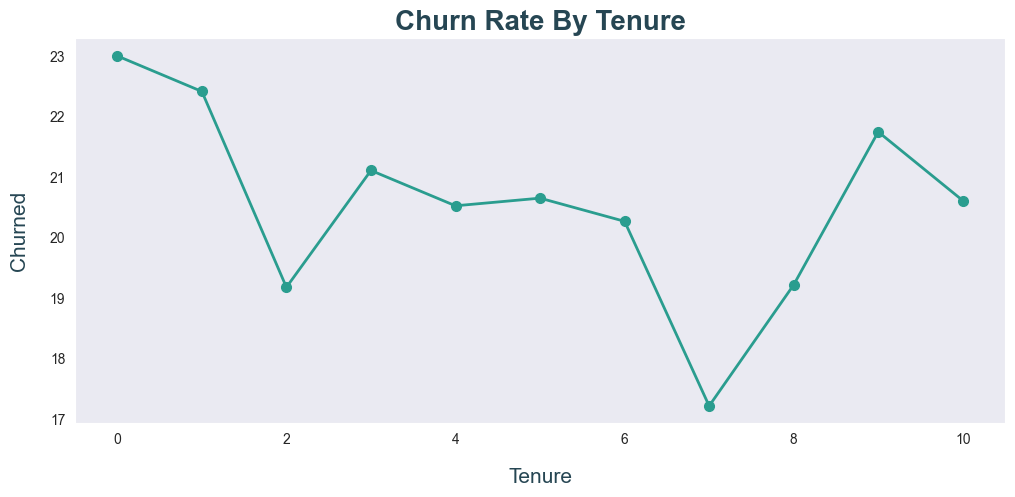

In [16]:
df["Tenure"].value_counts().sort_index()

tenure = df.groupby("Tenure")["Exited"].mean()*100

plt.figure(figsize=(12,5))
plt.plot(tenure.index, tenure.values, linewidth=2,color="#2A9D8F",marker="o", markersize=7)
plt.title("Churn Rate By Tenure",fontsize=20,color="#264653", fontweight="bold")
plt.xlabel("Tenure",fontsize=15,color="#264653",labelpad=15)
plt.ylabel("Churned",fontsize=15,color="#264653",labelpad=15)
plt.savefig("Churn Rate By Tenure (c1).png", dpi=300, bbox_inches='tight')
plt.show()

Churn stays fairly flat across tenure years, moving between 17% and 23%. Tenure alone does not explain churn well.

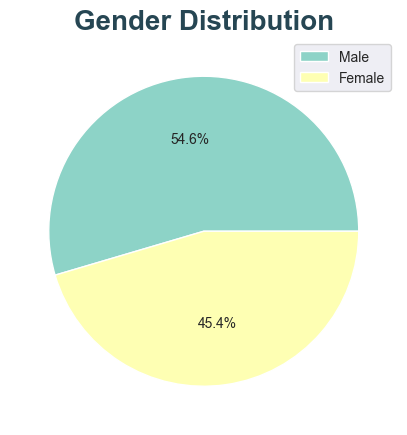

In [17]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(5,8))
plt.pie(gender.values, autopct= "%1.1f%%")
plt.legend(gender.index)
plt.title("Gender Distribution",fontsize=20,color="#264653", fontweight="bold")
plt.savefig("Gender Distribution (c2).png", dpi=300, bbox_inches='tight')
plt.show()

The customer base is close to 55% male and 45% female. About 1 in 5 customers has churned, which matches the churn rate found earlier.

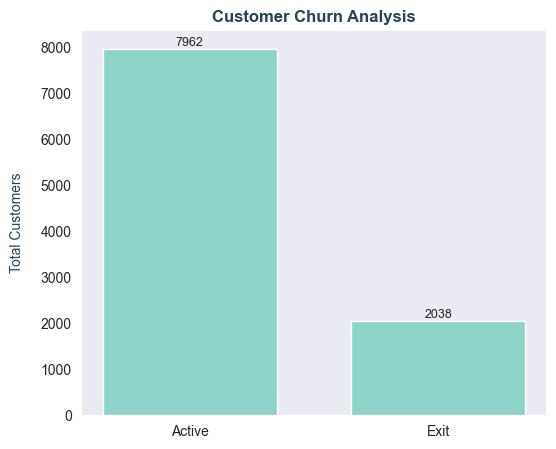

In [34]:
exited = df["Exited"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(["Active","Exit"], exited.values,width=0.7)
plt.title("Customer Churn Analysis",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
for i in range(len(exited)):
    plt.text(i, exited[i] + 70, exited[i], ha="center",fontsize=9)
plt.savefig("Customer Churn Analysis (c3).png", dpi=300, bbox_inches='tight')
plt.show()

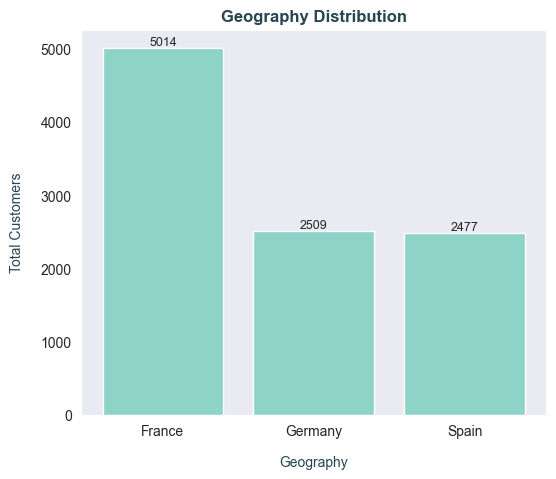

In [19]:
geo = df["Geography"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(geo.index, geo.values)
plt.title("Geography Distribution",fontsize=12,color="#264653",fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Geography",fontsize=10,color="#264653",labelpad=12)
for i in range(len(geo)):
    plt.text(i, geo.values[i]+40, geo.values[i], ha="center",fontsize=9)
plt.savefig("Geography Distribution (c4).png", dpi=300, bbox_inches='tight')
plt.show()

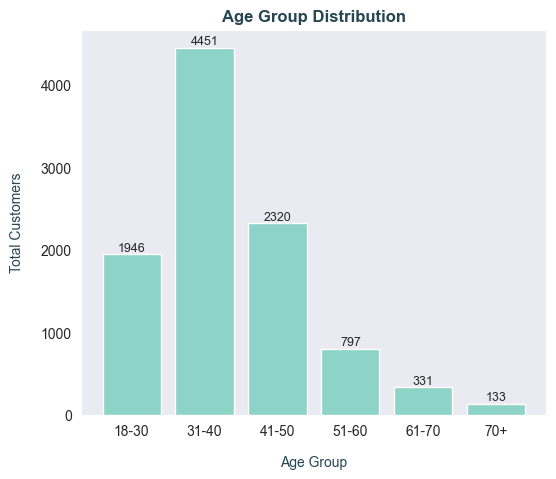

In [20]:
age = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(age.index, age.values)
plt.title("Age Group Distribution",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Age Group",fontsize=10,color="#264653",labelpad=12)
for i in range(len(age)):
    plt.text(i, age.values[i]+40, age.values[i], ha="center",fontsize=9)
plt.savefig("Age Group Distribution (c5).png", dpi=300, bbox_inches='tight')
plt.show()

France has the most customers, followed by Germany and Spain which are close in size. Most customers are between 31 to 40 years old.

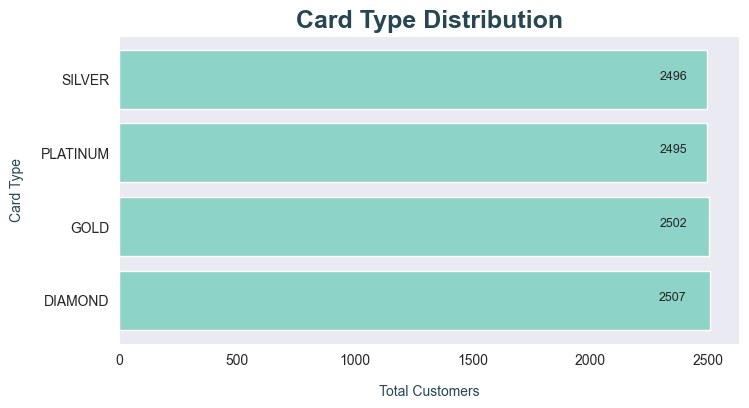

In [21]:
cards = df["Card Type"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.barh(cards.index, cards.values)
plt.title("Card Type Distribution",fontsize=18,color="#264653", fontweight="bold")
plt.ylabel("Card Type",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
for i in range(len(cards)):
    plt.text(i+2350, i, cards.values[i], ha="center",fontsize=9)
plt.savefig("Card Type Distribution (c6).png", dpi=300, bbox_inches='tight')
plt.show()

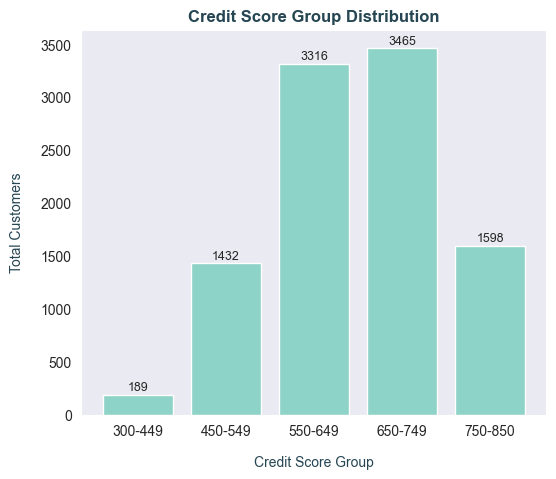

In [22]:
credit = df["Credit Score Group"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(credit.index, credit.values)
plt.title("Credit Score Group Distribution",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Credit Score Group",fontsize=10,color="#264653",labelpad=12)
for i in range(len(credit)):
    plt.text(i, credit.values[i]+40, credit.values[i], ha="center",fontsize=9)
plt.savefig("Credit Score Group Distribution (c7).png", dpi=300, bbox_inches='tight')
plt.show()

Card types are almost equally distributed, so card type is probably not a big factor. Most credit scores fall between 550 and 750, which is normal.

In [23]:
df.rename(columns={"NumOfProducts" : "Products"},inplace=True)

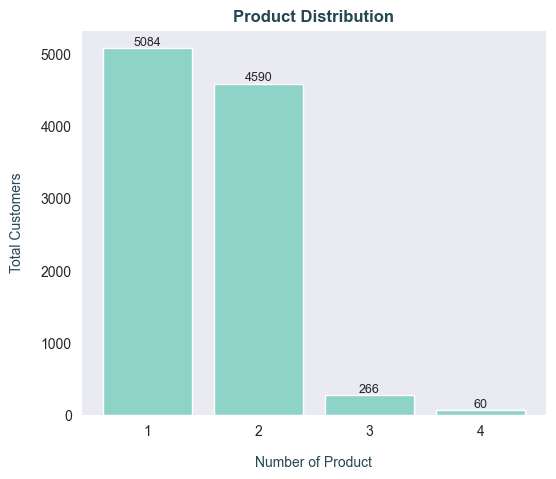

In [24]:
product = df["Products"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(product.index, product.values)
plt.title("Product Distribution",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Number of Product",fontsize=10,color="#264653",labelpad=12)
plt.xticks([1,2,3,4])
for i in range(len(product)):
    plt.text(product.index[i], product.values[i]+40, product.values[i], ha="center",fontsize=9)
plt.savefig("Product Distributionn (c8).png", dpi=300, bbox_inches='tight')
plt.show()

Most customers use 1 or 2 products. Very few use 3 or 4. Worth checking if fewer products means higher churn risk.

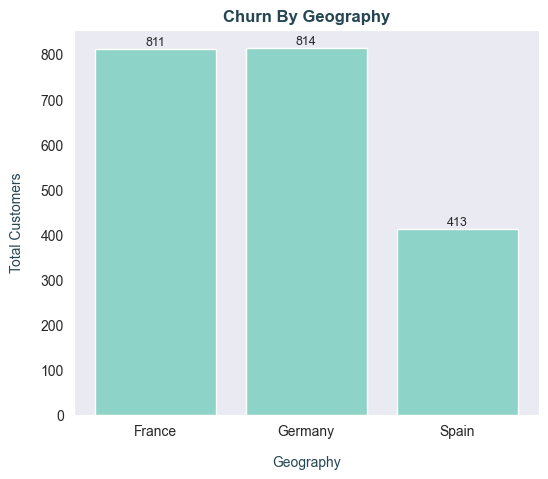

In [25]:
GeoChurn = df.groupby("Geography")["Exited"].sum().sort_index()

plt.figure(figsize=(6,5))
plt.bar(GeoChurn.index, GeoChurn.values)
plt.title("Churn By Geography",fontsize=12,color="#264653",fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Geography",fontsize=10,color="#264653",labelpad=12)
for i in range(len(GeoChurn)):
    plt.text(i, GeoChurn.values[i]+8, GeoChurn.values[i], ha="center",fontsize=9)
plt.savefig("Churn By Geography (c9).png", dpi=300, bbox_inches='tight')
plt.show()

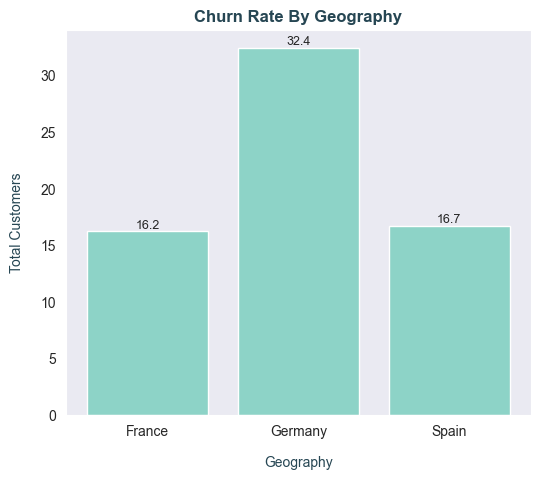

In [26]:
GeoChurn = (df.groupby("Geography")["Exited"].mean()*100).round(1)

plt.figure(figsize=(6,5))
plt.bar(GeoChurn.index, GeoChurn.values)
plt.title("Churn Rate By Geography",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Geography",fontsize=10,color="#264653",labelpad=12)
for i in range(len(GeoChurn)):
    plt.text(i, GeoChurn.values[i]+0.3, GeoChurn.values[i], ha="center",fontsize=9)
plt.savefig("Churn Rate By Geography (c10).png", dpi=300, bbox_inches='tight')
plt.show()

Germany stands out here. Even with fewer customers than France, Germany has a much higher churn rate (around 32%) compared to France and Spain (around 16%). This needs a closer look.

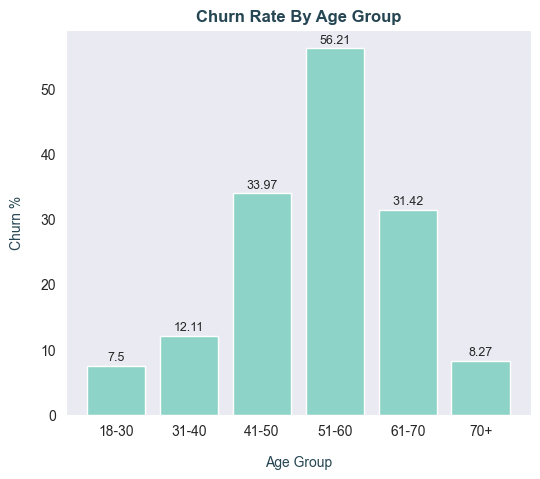

In [27]:
Churned = (df.groupby("Age Group")["Exited"].mean()*100).round(2)

plt.figure(figsize=(6,5))
plt.bar(Churned.index, Churned.values)
plt.title("Churn Rate By Age Group",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Churn %",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Age Group",fontsize=10,color="#264653",labelpad=12)
# plt.legend(["Churn Rate"])
for i in range(len(Churned)):
    plt.text(i, Churned.values[i]+0.8, Churned.values[i], ha="center",fontsize=9)
plt.savefig("Churn Rate By Age Group (c11).png", dpi=300, bbox_inches='tight')
plt.show()


Churn rises sharply for customers aged 51-60. Younger customers (18-30) stay the most loyal. The bank may be losing older, high-value customers.

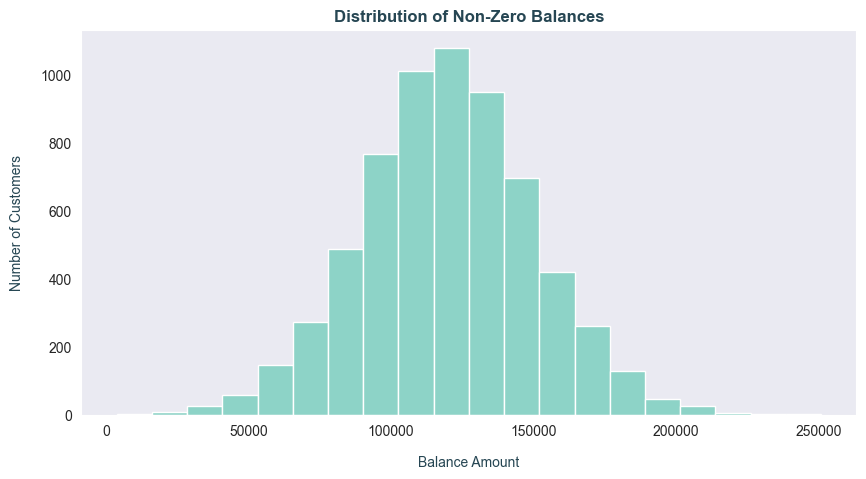

In [28]:
bal = df[df["Balance"]>0]["Balance"]
# bal.count()
plt.figure(figsize=(10,5))
plt.hist(bal, bins=20)
plt.title("Distribution of Non-Zero Balances", fontsize=12, color="#264653", fontweight="bold")
plt.xlabel("Balance Amount", fontsize=10, color="#264653", labelpad=12)
plt.ylabel("Number of Customers", fontsize=10, color="#264653", labelpad=12)
plt.savefig("Distribution Of Non-Zero Balances (c12).png", dpi=300, bbox_inches='tight')
plt.show()

Most customers hold a moderate balance, with fewer customers holding very high balances.

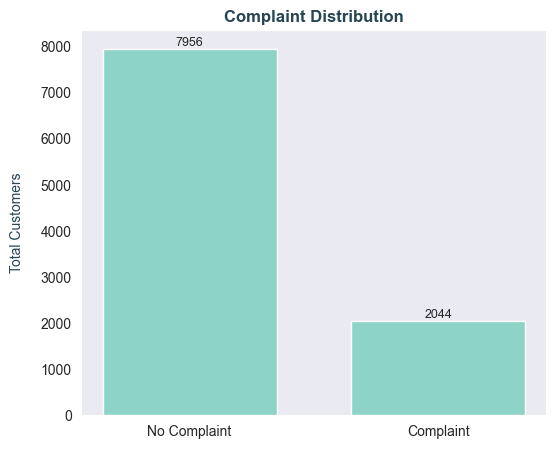

In [29]:
complain = df["Complain"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(["No Complaint","Complaint"], complain.values,width=0.7)
plt.title("Complaint Distribution",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
for i in range(len(complain)):
    plt.text(i, complain.values[i] + 70, complain.values[i], ha="center",fontsize=9)
plt.savefig("Complaint Distribution (c13).png", dpi=300, bbox_inches='tight')
plt.show()

Out of 10,000 customers, 2,044 have filed a complaint. That is about 1 in every 5 customers, almost the same number as customers who churned.

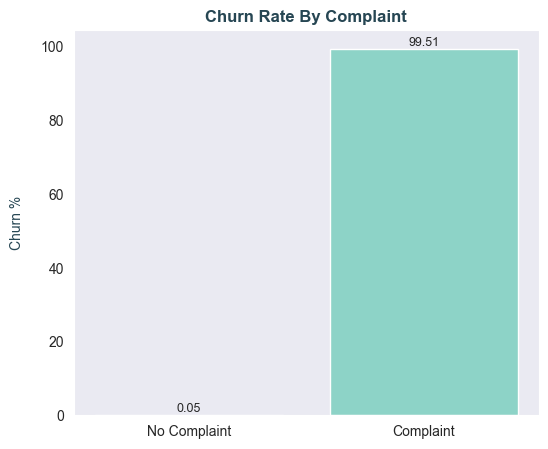

In [30]:
ComplainChurn = (df.groupby("Complain")["Exited"].mean()*100).round(2)

plt.figure(figsize=(6,5))
plt.bar(["No Complaint","Complaint"], ComplainChurn.values)
plt.title("Churn Rate By Complaint",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Churn %",fontsize=10,color="#264653",labelpad=12)
for i in range(len(ComplainChurn)):
    plt.text(i, ComplainChurn.values[i]+0.8, ComplainChurn.values[i], ha="center",fontsize=9)
plt.savefig("Churn Rate By Complaint (c14).png", dpi=300, bbox_inches='tight')
plt.show()

This is the biggest finding in the whole analysis. Customers who filed a complaint churned 99.5% of the time, while customers with no complaint churned only 0.05% of the time. A complaint is almost a guaranteed sign that the customer will leave.

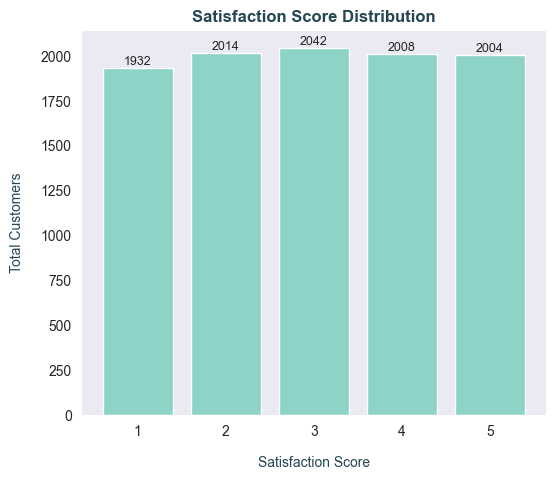

In [31]:
satisfaction = df["Satisfaction Score"].value_counts().sort_index()

plt.figure(figsize=(6,5))
plt.bar(satisfaction.index, satisfaction.values)
plt.title("Satisfaction Score Distribution",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Total Customers",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Satisfaction Score",fontsize=10,color="#264653",labelpad=12)
plt.xticks([1,2,3,4,5])
for i in range(len(satisfaction)):
    plt.text(satisfaction.index[i], satisfaction.values[i]+20, satisfaction.values[i], ha="center",fontsize=9)
plt.savefig("Satisfication Score Distribution (c15).png", dpi=300, bbox_inches='tight')
plt.show()

Satisfaction scores are almost evenly spread from 1 to 5, with each score having roughly 2,000 customers.

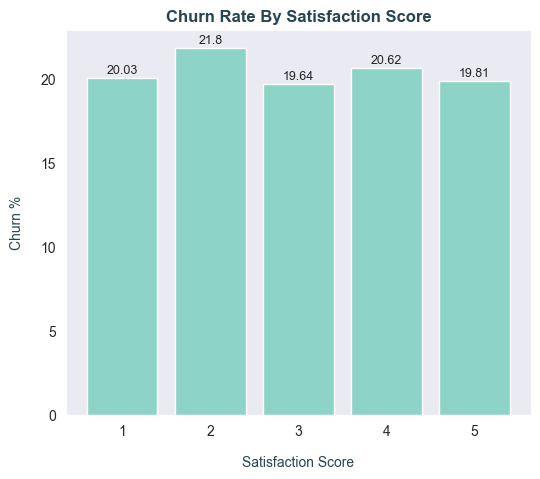

In [32]:
SatisfactionChurn = (df.groupby("Satisfaction Score")["Exited"].mean()*100).round(2)

plt.figure(figsize=(6,5))
plt.bar(SatisfactionChurn.index, SatisfactionChurn.values)
plt.title("Churn Rate By Satisfaction Score",fontsize=12,color="#264653", fontweight="bold")
plt.ylabel("Churn %",fontsize=10,color="#264653",labelpad=12)
plt.xlabel("Satisfaction Score",fontsize=10,color="#264653",labelpad=12)
plt.xticks([1,2,3,4,5])
for i in range(len(SatisfactionChurn)):
    plt.text(SatisfactionChurn.index[i], SatisfactionChurn.values[i]+0.3, SatisfactionChurn.values[i], ha="center",fontsize=9)
plt.savefig("Churn Rate By Satisfication Score (c16).png", dpi=300, bbox_inches='tight')
plt.show()

Churn rate stays close to 20% no matter the satisfaction score, from score 1 all the way to score 5. So satisfaction score does not predict churn. A customer's complaint history matters far more than how satisfied they say they are.

## Key Takeaways

- Overall churn rate is 20.4%, which is high for a bank
- Filing a complaint is the strongest sign of churn, 99.5% of customers who complained ended up leaving
- Satisfaction score barely affects churn, even highly satisfied customers leave if they had a complaint
- Germany has the highest churn rate at 32.4%, much higher than France and Spain, despite having fewer customers
- Churn rises sharply with age, peaking at 56.2% for customers aged 51-60
- The bank should focus on resolving complaints quickly and reviewing its process in Germany, since these are the strongest drivers of customer loss